In [12]:
import requests
import websocket
import json
import pandas as pd
import os 
import dotenv
from binance.client import Client
import sqlite3
import matplotlib.pyplot as plt

### REST API (Request-Response Model) ###
How it works:

The client (you) sends a request → The server (Binance API) responds.
Every new request needs a separate HTTP call (adds delay).
📌 Example: Getting BTC/USDT price using REST API

In [14]:
url = "https://api.binance.com/api/v3/ticker/price"
params = {"symbol": "BTCUSDT"}

response = requests.get(url, params=params).json()

In [15]:
print(type(response))
print(response)

<class 'dict'>
{'symbol': 'BTCUSDT', 'price': '88894.73000000'}


### Fetch Historical Candlestick (Kline) Data ###
You can fetch OHLCV (Open, High, Low, Close, Volume) data using the klines endpoint.

🔹 Example: Get BTC/USDT 1-minute candles (last 5 entries)

In [18]:
# Binance API endpoint
url = "https://api.binance.com/api/v3/klines"

# Parameters for BTC/USDT 1-minute candles
params = {
    "symbol": "BTCUSDT",
    "interval": "1m",  # Timeframe: 1m, 5m, 1h, 1d, etc.
    "limit": 5  # Number of candles to fetch
}

# Fetch data
response = requests.get(url, params=params).json()

In [19]:
print(response)

[[1740555720000, '88446.09000000', '88535.43000000', '88446.09000000', '88515.63000000', '26.69687000', 1740555779999, '2362389.21484980', 4832, '8.43910000', '746749.22789390', '0'], [1740555780000, '88515.62000000', '88544.57000000', '88515.62000000', '88539.79000000', '18.57680000', 1740555839999, '1644745.47553890', 2381, '12.01619000', '1063863.92718610', '0'], [1740555840000, '88539.79000000', '88582.84000000', '88539.78000000', '88582.84000000', '21.98741000', 1740555899999, '1947216.90836870', 1700, '16.00671000', '1417489.03965060', '0'], [1740555900000, '88582.83000000', '88591.98000000', '88541.20000000', '88576.53000000', '12.95513000', 1740555959999, '1147451.91335630', 3721, '7.34783000', '650782.44954590', '0'], [1740555960000, '88576.53000000', '88598.27000000', '88536.57000000', '88554.59000000', '15.08213000', 1740556019999, '1335844.73854950', 1513, '2.58233000', '228731.92201970', '0']]


In [28]:
# Convert response to DataFrame
columns = ["timestamp", "open", "high", "low", "close", "volume", "close_time", "quote_asset_volume", "trades", "taker_buy_base", "taker_buy_quote", "ignore"]
df = pd.DataFrame(response, columns=columns)
df = df.astype(float)

# Convert timestamp to readable date
df["timestamp"] = pd.to_datetime(df["timestamp"], unit="ms")

# Set the index column to timestamp
df.set_index("timestamp", inplace=True)

print(df[["open", "high", "low", "close", "volume"]].head())

                         open      high       low     close    volume
timestamp                                                            
2025-02-26 07:42:00  88446.09  88535.43  88446.09  88515.63  26.69687
2025-02-26 07:43:00  88515.62  88544.57  88515.62  88539.79  18.57680
2025-02-26 07:44:00  88539.79  88582.84  88539.78  88582.84  21.98741
2025-02-26 07:45:00  88582.83  88591.98  88541.20  88576.53  12.95513
2025-02-26 07:46:00  88576.53  88598.27  88536.57  88554.59  15.08213


Fetch & Store Historical Candlestick Data
We'll fetch historical OHLCV data from Binance and store it in SQLite.

In [31]:
# Function to get historical OHLCV data
def get_historical_data(symbol="BTCUSDT", interval="1m", limit=5):
    url = "https://api.binance.com/api/v3/klines"
    params = {
        "symbol": symbol,
        "interval": interval,
        "limit": limit
    }
    response = requests.get(url, params=params).json()

    # Convert response to Pandas DataFrame
    columns = ["timestamp", "open", "high", "low", "close", "volume", 
               "close_time", "quote_asset_volume", "trades", "taker_buy_base", "taker_buy_quote", "ignore"]
    df = pd.DataFrame(response, columns=columns)
    df[["open", "high", "low", "close", "volume"]] = df[["open", "high", "low", "close", "volume"]].astype(float)

    # Convert timestamp to readable datetime
    df["timestamp"] = pd.to_datetime(df["timestamp"], unit="ms")

    # Set the index column to timestamp
    df.set_index("timestamp", inplace=True)

    return df[["open", "high", "low", "close", "volume"]]

# Fetch & display last 5 BTC/USDT candles
df = get_historical_data("BTCUSDT", "1m", 5)
print(df)

                         open      high       low     close    volume
timestamp                                                            
2025-02-26 08:20:00  88264.16  88339.63  88264.15  88338.25  12.34679
2025-02-26 08:21:00  88338.25  88406.63  88320.11  88391.21  10.61798
2025-02-26 08:22:00  88391.21  88391.21  88302.69  88323.79  29.68785
2025-02-26 08:23:00  88323.79  88391.20  88323.78  88390.15   7.23973
2025-02-26 08:24:00  88390.15  88399.73  88345.54  88347.99   9.69882


In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 5 entries, 2025-02-26 08:20:00 to 2025-02-26 08:24:00
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   open    5 non-null      float64
 1   high    5 non-null      float64
 2   low     5 non-null      float64
 3   close   5 non-null      float64
 4   volume  5 non-null      float64
dtypes: float64(5)
memory usage: 240.0 bytes


### WebSocket (Real-Time Data Stream) ###
How it works:

The client opens a connection → The server keeps sending updates automatically.
No need to send requests repeatedly (low latency).
📌 Example: Streaming real-time BTC/USDT trades using WebSocket

In [ ]:
def on_message(ws, message):
    trade = json.loads(message)
    print(f"Trade - Price: {trade['p']}, Quantity: {trade['q']}")

socket = "wss://stream.binance.com:9443/ws/btcusdt@trade"

ws = websocket.WebSocketApp(socket, on_message=on_message)
ws.run_forever()

Trade - Price: 88484.56000000, Quantity: 0.03389000
Trade - Price: 88484.56000000, Quantity: 0.03389000
Trade - Price: 88484.56000000, Quantity: 0.03389000
Trade - Price: 88484.56000000, Quantity: 0.03389000
Trade - Price: 88484.56000000, Quantity: 0.03389000
Trade - Price: 88484.56000000, Quantity: 0.03389000
Trade - Price: 88484.56000000, Quantity: 0.03389000
Trade - Price: 88484.56000000, Quantity: 0.03389000
Trade - Price: 88484.56000000, Quantity: 0.03389000
Trade - Price: 88484.56000000, Quantity: 0.03389000
Trade - Price: 88484.56000000, Quantity: 0.00885000
Trade - Price: 88484.55000000, Quantity: 0.00150000
Trade - Price: 88484.55000000, Quantity: 0.00679000
Trade - Price: 88484.56000000, Quantity: 0.00065000
Trade - Price: 88484.56000000, Quantity: 0.02259000
Trade - Price: 88484.55000000, Quantity: 0.00022000


True

In [ ]:
# Load API keys from .env file
dotenv.load_dotenv()

API_KEY = os.getenv("BINANCE_API_KEY")
API_SECRET = os.getenv("BINANCE_SECRET_KEY")

# Initialize Binance Client
client = Client(API_KEY, API_SECRET)


 ### Create SQLite Database & Tables ###
Now, let's set up our database and create tables for historical data & trade executions.

Using pd.to_sql()

In [37]:
# Connect to the SQLite database
conn = sqlite3.connect("trading_data.db")

# Store DataFrame into SQLite using pandas .to_sql()
df.to_sql("historical_data", conn, if_exists="replace", index=True)

conn.close()
print("✅ Data inserted using .to_sql()")

✅ Data inserted using .to_sql()


Using Manual SQL Inserts (INSERT INTO)

In [47]:
%%capture
%load_ext sql
%sql sqlite://trading_data.db

In [48]:
%%sql
SELECT * FROM historical_data

UsageError: Cell magic `%%sql` not found.


In [41]:
def insert_historical_data(symbol, df):
    """Store OHLCV data in SQLite, ensuring timestamp is indexed"""
    conn = sqlite3.connect("trading_data.db")
    cursor = conn.cursor()

    # Reset index so timestamp becomes a column
    df = df.reset_index()

    # Batch insert
    data = [(symbol, row["timestamp"], row["open"], row["high"], row["low"], row["close"], row["volume"]) for _, row in df.iterrows()]
    
    cursor.executemany('''
        INSERT INTO historical_data (symbol, timestamp, open, high, low, close, volume)
        VALUES (?, ?, ?, ?, ?, ?, ?)
    ''', data)

    conn.commit()
    conn.close()
    print(f"✅ {len(df)} rows inserted for {symbol}")

# Example usage:
insert_historical_data("BTCUSDT", df)


OperationalError: table historical_data has no column named symbol

In [54]:
def create_table(symbol):
    """Creates a table for the given symbol if it does not exist."""
    conn = sqlite3.connect("trading_data.db")
    cursor = conn.cursor()

    query = f'''
    CREATE TABLE IF NOT EXISTS {symbol} (
        timestamp INTEGER PRIMARY KEY,
        open REAL,
        high REAL,
        low REAL,
        close REAL,
        volume REAL
    )
    '''
    cursor.execute(query)
    conn.commit()
    conn.close()

    print(f"✅ Table {symbol} is ready.")


In [55]:
def insert_historical_data(symbol, df):
    """Insert OHLCV data into a table named after the symbol."""
    conn = sqlite3.connect("trading_data.db")
    cursor = conn.cursor()

    # Ensure table exists
    create_table(symbol)

    # Reset index so timestamp becomes a column
    df = df.reset_index()
    df["timestamp"] = df["timestamp"].astype(int)  # Converts Timestamp to UNIX integer


    # Prepare batch insert data
    data = [(row["timestamp"], row["open"], row["high"], row["low"], row["close"], row["volume"]) for _, row in df.iterrows()]
    
    # Insert data using executemany for efficiency
    query = f'''
        INSERT INTO {symbol} (timestamp, open, high, low, close, volume)
        VALUES (?, ?, ?, ?, ?, ?)
        ON CONFLICT(timestamp) DO NOTHING
    '''
    cursor.executemany(query, data)

    conn.commit()
    conn.close()
    print(f"✅ {len(df)} rows inserted into {symbol}.")



In [56]:
# Fetch historical data for BTCUSDT
df = get_historical_data("BTCUSDT", "1m", 5)

# Insert data into the BTCUSDT table
insert_historical_data("BTCUSDT", df)


✅ Table BTCUSDT is ready.
✅ 5 rows inserted into BTCUSDT.


In [1]:
from data import BinanceClient, DatabaseManager

In [4]:
binance = BinanceClient("BTCUSDT")

# Switch to another symbol
# binance.set_symbol("ETHUSDT")

# Fetch historical data
df = binance.get_historical_data()
print(df)

             timestamp      open      high       low     close     volume
0  2025-02-26 13:19:00  87595.94  87620.52  87518.47  87559.99  100.54279
1  2025-02-26 13:20:00  87559.99  87611.40  87536.00  87580.00   33.34966
2  2025-02-26 13:21:00  87580.00  87758.43  87580.00  87599.97   50.88742
3  2025-02-26 13:22:00  87599.97  87771.99  87582.00  87767.68   21.58732
4  2025-02-26 13:23:00  87767.67  87882.96  87761.91  87852.78   33.03107
..                 ...       ...       ...       ...       ...        ...
95 2025-02-26 14:54:00  87403.99  87741.33  87403.99  87708.63  200.17935
96 2025-02-26 14:55:00  87708.63  87708.63  87471.69  87471.69  103.04673
97 2025-02-26 14:56:00  87471.70  87568.00  87415.17  87531.99   61.28453
98 2025-02-26 14:57:00  87531.98  87531.98  87363.27  87440.01   63.52164
99 2025-02-26 14:58:00  87440.00  87512.40  87341.77  87502.01   53.46795

[100 rows x 6 columns]


In [5]:
# Initialize database (no need to specify a symbol)
db = DatabaseManager()

# Create tables dynamically
db.create_table("BTCUSDT")
db.create_table("ETHUSDT")

# Insert BTCUSDT data
# df_btc = binance.get_historical_data("BTCUSDT", "1m", 5)
# db.insert_historical_data("BTCUSDT", df_btc)
df_btc = df
db.insert_historical_data("BTCUSDT", df_btc)

# Insert ETHUSDT data
binance.set_symbol("ETHUSDT")
# Fetch historical data
df_eth = binance.get_historical_data()
db.insert_historical_data("ETHUSDT", df_eth)

# Read BTCUSDT data
print(db.read_data("BTCUSDT"))

# Close the database connection
db.close()

✅ Inserted 100 rows into data_BTCUSDT
✅ Trading pair set to ETHUSDT
✅ Inserted 100 rows into data_ETHUSDT
            timestamp      open      high       low     close     volume
0 2025-02-26 14:58:00  87440.00  87512.40  87341.77  87502.01   53.46795
1 2025-02-26 14:57:00  87531.98  87531.98  87363.27  87440.01   63.52164
2 2025-02-26 14:56:00  87471.70  87568.00  87415.17  87531.99   61.28453
3 2025-02-26 14:55:00  87708.63  87708.63  87471.69  87471.69  103.04673
4 2025-02-26 14:54:00  87403.99  87741.33  87403.99  87708.63  200.17935
5 2025-02-26 14:53:00  87450.85  87516.00  87317.04  87403.99  118.69450
6 2025-02-26 14:52:00  87307.98  87466.16  87154.00  87450.84  106.06416
7 2025-02-26 14:51:00  87148.85  87307.99  87089.35  87307.99  116.69294
8 2025-02-26 14:50:00  87303.40  87338.25  87132.00  87148.86  108.94123
9 2025-02-26 14:49:00  87253.47  87431.30  87253.03  87303.40  140.03667
🔴 Database connection closed.


Take a look at the dataframe. Explore the data.


In [6]:
df_btc.head()

,timestamp,open,high,low,close,volume
0,2025-02-26 13:19:00,87595.94,87620.52,87518.47,87559.99,100.54279
1,2025-02-26 13:20:00,87559.99,87611.40,87536.00,87580.00,33.34966
2,2025-02-26 13:21:00,87580.00,87758.43,87580.00,87599.97,50.88742
3,2025-02-26 13:22:00,87599.97,87771.99,87582.00,87767.68,21.58732
4,2025-02-26 13:23:00,87767.67,87882.96,87761.91,87852.78,33.03107


In [9]:
df_btc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   timestamp  100 non-null    datetime64[ns]
 1   open       100 non-null    float64       
 2   high       100 non-null    float64       
 3   low        100 non-null    float64       
 4   close      100 non-null    float64       
 5   volume     100 non-null    float64       
dtypes: datetime64[ns](1), float64(5)
memory usage: 4.8 KB


In [14]:
df_btc.set_index("timestamp", inplace=True)

<Axes: xlabel='timestamp'>

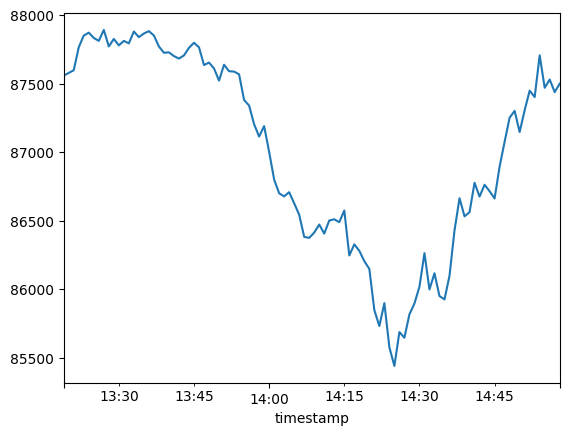

In [15]:
df_btc['close'].plot()